In [1]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, ReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

## 1. Основні налаштування

In [2]:
num_classes = 7
img_size = (224, 224)
batch_size = 32

train_data_dir = r'train'
validation_data_dir = r'test'

# 7 класів (типово для FER2013)
CLASS_NAMES = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]

In [3]:
epochs_head = 15          # тільки новий "класифікатор"
epochs_finetune = 10     # fine-tuning бази

## 2. Генератори даних

In [4]:

train_data = image_dataset_from_directory(
    train_data_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

validation_data = image_dataset_from_directory(
    validation_data_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [5]:
# Нормалізація /255
# grayscale треба перетворити на 3 канали (RGB)
def normalize_and_to_rgb(images, labels):
    images = tf.cast(images, tf.float32)

    # Якщо канал 1, зробимо RGB
    if images.shape.rank ==4 and images.shape[-1] ==1:
        images = tf.image.grayscale_to_rgb(images)

    images = images / 255.0
    return images, labels

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.map(normalize_and_to_rgb, 
                            num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
validation_data = validation_data.map(normalize_and_to_rgb, 
                            num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

## 3. MobileNetV2

In [7]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(img_size[0], img_size[1], 3)
)
base_model.trainable = False

# "Голова" класифікатора: Dense -> ReLU -> Dense -> ReLU -> Softmax(7)
inputs = Input(shape=(img_size[0], img_size[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

x = Dense(256)(x)
x = ReLU()(x)

x = Dense(128)(x)
x = ReLU()(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


## 4. Callbacks

In [9]:
checkpoint = ModelCheckpoint(
    'Emotion_mobilenetv2_7cls.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=1e-4
)

callbacks = [earlystop, checkpoint, reduce_lr]

## 5. ЕТАП 1: тренування тільки "голови"

In [10]:

steps_per_epoch = tf.data.experimental.cardinality(train_data).numpy()
validation_steps = tf.data.experimental.cardinality(validation_data).numpy()

print("\n=== Stage 1: train classifier head ===")
history_head = model.fit(
    train_data,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_head,
    validation_data=validation_data,
    validation_steps=validation_steps,
    callbacks=callbacks
)


=== Stage 1: train classifier head ===
Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.3555 - loss: 1.6382
Epoch 1: val_loss improved from inf to 1.41949, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 583s 644ms/step - accuracy: 0.3555 - loss: 1.6381 - val_accuracy: 0.4485 - val_loss: 1.4195 - learning_rate: 1.0000e-04
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.4778 - loss: 1.3774
Epoch 2: val_loss improved from 1.41949 to 1.35712, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 555s 618ms/step - accuracy: 0.4778 - loss: 1.3774 - val_accuracy: 0.4760 - val_loss: 1.3571 - learning_rate: 1.0000e-04
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.5135 - loss: 1.3008
Epoch 3: val_loss improved from 1.35712 to 1.33205, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 548s 611ms/step - accuracy: 0.5135 - loss: 1.3008 - val_accuracy: 0.4909 - val_loss: 1.3321 - learning_rate: 1.0000e-04
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.5386 - loss: 1.2423
Epoch 4: val_loss improved from 1.33205 to 1.30449, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 546s 608ms/step - accuracy: 0.5386 - loss: 1.2423 - val_accuracy: 0.5014 - val_loss: 1.3045 - learning_rate: 1.0000e-04
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.5563 - loss: 1.1963
Epoch 5: val_loss did not improve from 1.30449
898/898 ━━━━━━━━━━━━━━━━━━━━ 547s 609ms/step - accuracy: 0.5563 - loss: 1.1963 - val_accuracy: 0.5000 - val_loss: 1.3134 - learning_rate: 1.0000e-04
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5774 - loss: 1.1505
Epoch 6: val_loss improved from 1.30449 to 1.28543, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 551s 613ms/step - accuracy: 0.5774 - loss: 1.1505 - val_accuracy: 0.5135 - val_loss: 1.2854 - learning_rate: 1.0000e-04
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.5919 - loss: 1.1106
Epoch 7: val_loss improved from 1.28543 to 1.28210, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 548s 610ms/step - accuracy: 0.5919 - loss: 1.1106 - val_accuracy: 0.5139 - val_loss: 1.2821 - learning_rate: 1.0000e-04
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6125 - loss: 1.0686
Epoch 8: val_loss did not improve from 1.28210
898/898 ━━━━━━━━━━━━━━━━━━━━ 547s 610ms/step - accuracy: 0.6125 - loss: 1.0686 - val_accuracy: 0.5135 - val_loss: 1.2934 - learning_rate: 1.0000e-04
Epoch 9/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.6323 - loss: 1.0243
Epoch 9: val_loss did not improve from 1.28210
898/898 ━━━━━━━━━━━━━━━━━━━━ 541s 602ms/step - accuracy: 0.6323 - loss: 1.0243 - val_accuracy: 0.5109 - val_loss: 1.2929 - learning_rate: 1.0000e-04
Epoch 10/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6472 - loss: 0.9885
Epoch 10: val_loss did not improve from 1.28210

Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
898/898 ━━━━━━━━━━━━━━━━━━━━ 524s 584ms/step - accuracy: 0.6472 - l

898/898 ━━━━━━━━━━━━━━━━━━━━ 527s 587ms/step - accuracy: 0.6699 - loss: 0.9378 - val_accuracy: 0.5319 - val_loss: 1.2597 - learning_rate: 2.0000e-05
Epoch 12/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.6795 - loss: 0.9150
Epoch 12: val_loss improved from 1.25969 to 1.25919, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 526s 586ms/step - accuracy: 0.6795 - loss: 0.9149 - val_accuracy: 0.5325 - val_loss: 1.2592 - learning_rate: 2.0000e-05
Epoch 13/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6858 - loss: 0.9035
Epoch 13: val_loss did not improve from 1.25919
898/898 ━━━━━━━━━━━━━━━━━━━━ 525s 584ms/step - accuracy: 0.6858 - loss: 0.9034 - val_accuracy: 0.5316 - val_loss: 1.2627 - learning_rate: 2.0000e-05
Epoch 14/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.6899 - loss: 0.8906
Epoch 14: val_loss did not improve from 1.25919
898/898 ━━━━━━━━━━━━━━━━━━━━ 551s 614ms/step - accuracy: 0.6899 - loss: 0.8906 - val_accuracy: 0.5343 - val_loss: 1.2610 - learning_rate: 2.0000e-05
Epoch 15/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.6942 - loss: 0.8812
Epoch 15: val_loss did not improve from 1.25919

Epoch 15: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
898/898 ━━━━━━━━━━━━━━━━━━━━ 546s 608ms/step - accuracy: 0.6942 

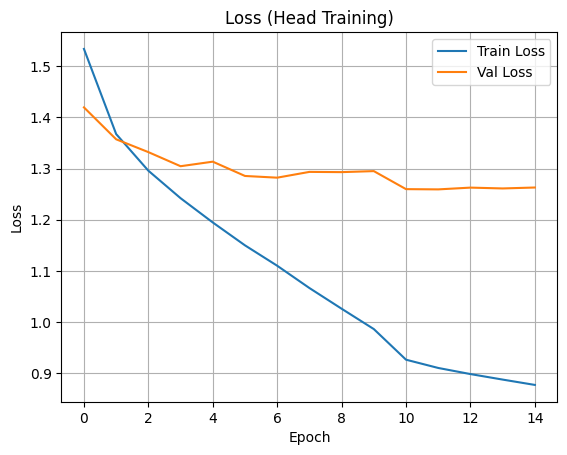

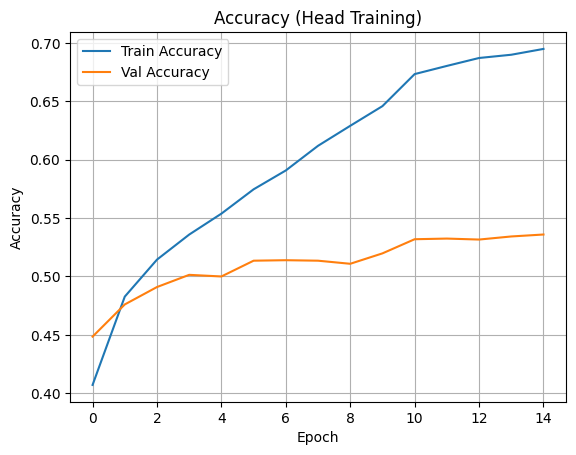

In [11]:
# Графіків після навчання "голови"
plt.figure()
plt.plot(history_head.history['loss'], label='Train Loss')
plt.plot(history_head.history['val_loss'], label='Val Loss')
plt.title('Loss (Head Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history_head.history['accuracy'], label='Train Accuracy')
plt.plot(history_head.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy (Head Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 113s 498ms/step
Validation Accuracy after Head Training: 0.5324602953468933


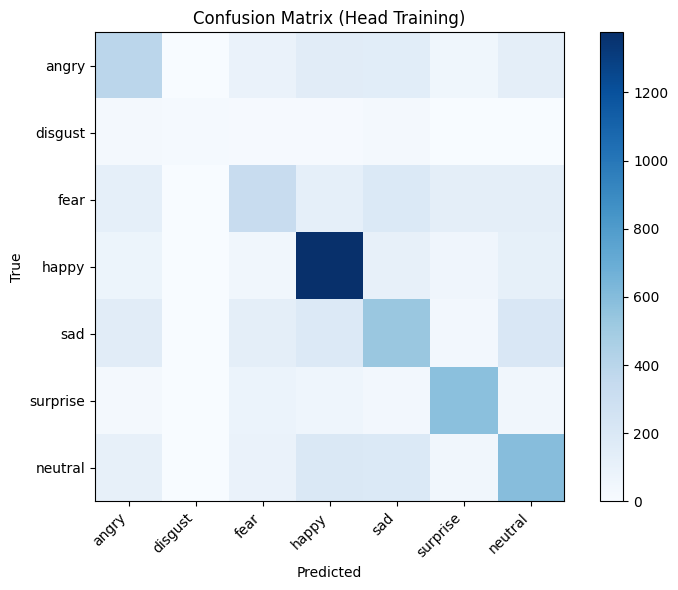

Classification Report after Head Training:
               precision    recall  f1-score   support

       angry     0.4326    0.4050    0.4183       958
     disgust     0.7241    0.1892    0.3000       111
        fear     0.4208    0.3242    0.3662      1024
       happy     0.6524    0.7756    0.7087      1774
         sad     0.4324    0.4258    0.4291      1247
    surprise     0.6448    0.6968    0.6698       831
     neutral     0.4845    0.4826    0.4835      1233

    accuracy                         0.5325      7178
   macro avg     0.5417    0.4713    0.4822      7178
weighted avg     0.5232    0.5325    0.5230      7178



In [12]:
# === Прогнози на валідаційному наборі
y_prob = model.predict(validation_data)
y_pred = np.argmax(y_prob, axis=1)

# === Отримуємо справжні мітки
y_true = np.concatenate([y for x, y in validation_data], axis=0)

# === Оцінка
val_acc = accuracy_score(y_true, y_pred)
print("Validation Accuracy after Head Training:", val_acc)

# === Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = CLASS_NAMES  # Визначено раніше

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Confusion Matrix (Head Training)")
plt.tight_layout()
plt.show()

# === Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report after Head Training:\n", report)

## 6. ЕТАП 2: fine-tuning останніх шарів бази

In [13]:
# === Розморозити верхні шари базової моделі для fine-tuning ===
base_model.trainable = True

# Заморозити нижні шари (залишити тільки верхні ~40 шарів trainable)
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Скомпілювати модель із меншою швидкістю навчання
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


In [14]:
print("\n=== Stage 2: Fine-tuning base model ===")
history_ft = model.fit(
    train_data,
    epochs=10,  # або більше при потребі
    validation_data=validation_data,
    callbacks=callbacks  # той самий список: earlystop, checkpoint, reduce_lr
)


=== Stage 2: Fine-tuning base model ===
Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.3735 - loss: 1.7102
Epoch 1: val_loss did not improve from 1.25919
898/898 ━━━━━━━━━━━━━━━━━━━━ 716s 787ms/step - accuracy: 0.3735 - loss: 1.7100 - val_accuracy: 0.4806 - val_loss: 1.4488 - learning_rate: 1.0000e-05
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.5287 - loss: 1.2526
Epoch 2: val_loss did not improve from 1.25919
898/898 ━━━━━━━━━━━━━━━━━━━━ 739s 823ms/step - accuracy: 0.5288 - loss: 1.2525 - val_accuracy: 0.5057 - val_loss: 1.3184 - learning_rate: 1.0000e-05
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.5885 - loss: 1.1175
Epoch 3: val_loss improved from 1.25919 to 1.24481, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 743s 827ms/step - accuracy: 0.5885 - loss: 1.1175 - val_accuracy: 0.5333 - val_loss: 1.2448 - learning_rate: 1.0000e-05
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.6365 - loss: 1.0086
Epoch 4: val_loss improved from 1.24481 to 1.22522, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 744s 829ms/step - accuracy: 0.6365 - loss: 1.0086 - val_accuracy: 0.5479 - val_loss: 1.2252 - learning_rate: 1.0000e-05
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.6685 - loss: 0.9197
Epoch 5: val_loss improved from 1.22522 to 1.21589, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 738s 822ms/step - accuracy: 0.6685 - loss: 0.9197 - val_accuracy: 0.5548 - val_loss: 1.2159 - learning_rate: 1.0000e-05
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7011 - loss: 0.8338
Epoch 6: val_loss improved from 1.21589 to 1.20320, saving model to Emotion_mobilenetv2_7cls.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 732s 815ms/step - accuracy: 0.7011 - loss: 0.8338 - val_accuracy: 0.5653 - val_loss: 1.2032 - learning_rate: 1.0000e-05
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7346 - loss: 0.7514
Epoch 7: val_loss did not improve from 1.20320
898/898 ━━━━━━━━━━━━━━━━━━━━ 731s 814ms/step - accuracy: 0.7346 - loss: 0.7513 - val_accuracy: 0.5674 - val_loss: 1.2133 - learning_rate: 1.0000e-05
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7663 - loss: 0.6683
Epoch 8: val_loss did not improve from 1.20320
898/898 ━━━━━━━━━━━━━━━━━━━━ 731s 814ms/step - accuracy: 0.7663 - loss: 0.6683 - val_accuracy: 0.5723 - val_loss: 1.2323 - learning_rate: 1.0000e-05
Epoch 9/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.7978 - loss: 0.5971
Epoch 9: val_loss did not improve from 1.20320

Epoch 9: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
898/898 ━━━━━━━━━━━━━━━━━━━━ 702s 782ms/step - accuracy: 0.7978 - loss

In [15]:
# === Об'єднання історій head + fine-tune ===
history_combined = {}
for key in history_head.history:
    history_combined[key] = history_head.history[key] + history_ft.history.get(key, [])


## 7. Learning loss / accuracy

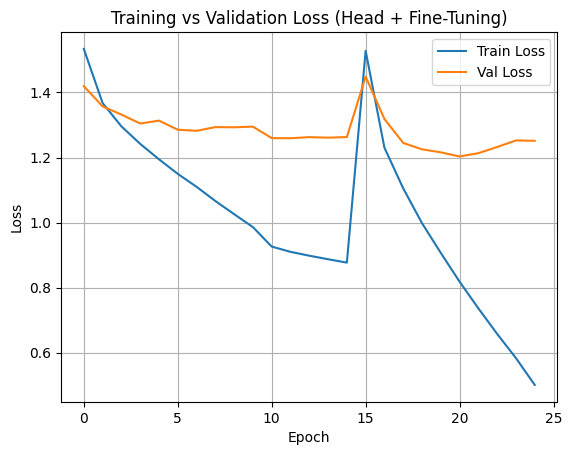

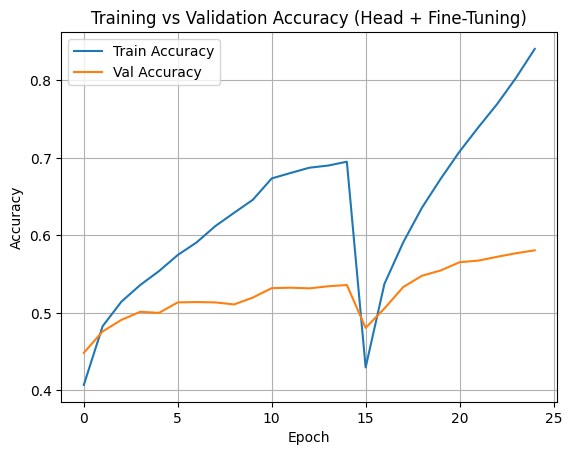

In [16]:
plt.figure()
plt.plot(history_combined['loss'], label='Train Loss')
plt.plot(history_combined['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss (Head + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history_combined['accuracy'], label='Train Accuracy')
plt.plot(history_combined['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy (Head + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 8. Оцінка моделі на validation set
###    (accuracy, confusion matrix)

225/225 ━━━━━━━━━━━━━━━━━━━━ 108s 476ms/step
Validation Accuracy after Fine-Tuning: 0.5653385344106994


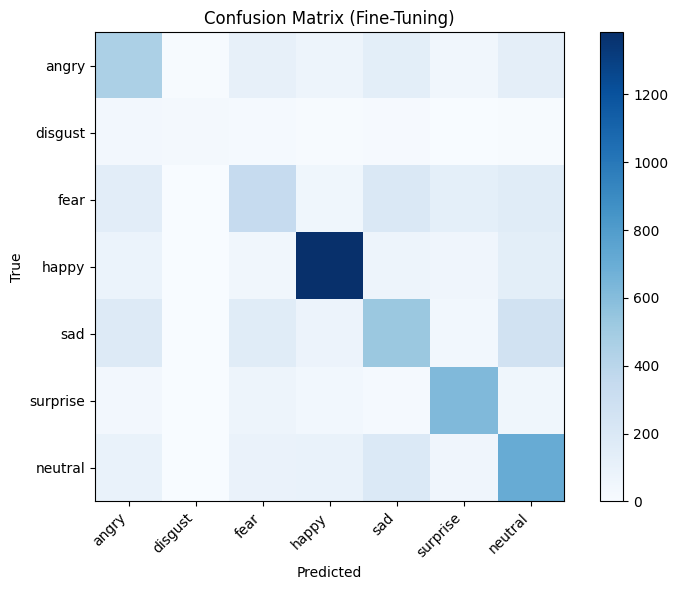

Classification Report after Fine-Tuning:
               precision    recall  f1-score   support

       angry     0.4450    0.4770    0.4605       958
     disgust     0.5652    0.2342    0.3312       111
        fear     0.4135    0.3359    0.3707      1024
       happy     0.8031    0.7796    0.7912      1774
         sad     0.4557    0.4210    0.4377      1247
    surprise     0.6543    0.7425    0.6956       831
     neutral     0.4849    0.5726    0.5251      1233

    accuracy                         0.5653      7178
   macro avg     0.5460    0.5090    0.5160      7178
weighted avg     0.5638    0.5653    0.5618      7178



In [17]:
# === Прогнозування на validation data
y_prob_ft = model.predict(validation_data)
y_pred_ft = np.argmax(y_prob_ft, axis=1)
y_true_ft = np.concatenate([y for x, y in validation_data], axis=0)

# === Оцінка якості
val_acc_ft = accuracy_score(y_true_ft, y_pred_ft)
print("Validation Accuracy after Fine-Tuning:", val_acc_ft)

# === Матриця плутанини
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_ft, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Confusion Matrix (Fine-Tuning)")
plt.tight_layout()
plt.show()

# === Classification report
report_ft = classification_report(y_true_ft, y_pred_ft, target_names=CLASS_NAMES, digits=4)
print("Classification Report after Fine-Tuning:\n", report_ft)


In [18]:

# === Збереження остаточної моделі
model.save("Emotion_mobilenetv2_7cls_finetuned.h5")